In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# SETTINGS

RESULTS_DIR = Path(".")   #  *.json result files
BASELINE_MODEL = "SARIMA"
BOOTSTRAP_B = 5000
RANDOM_SEED = 123
metric_name = "MSE"


np.random.seed(123)

# 2. LOAD RESULTS

def load_results(results_dir):
    results = {}
    for fp in sorted(results_dir.glob("*.json")):
        with open(fp, "r") as f:
            obj = json.load(f)
        name = obj["model_name"]
        obj["cv_errors"] = np.array(obj["cv_errors"], dtype=float)
        obj["holdout_actual"] = np.array(obj["holdout_actual"], dtype=float)
        obj["holdout_pred"] = np.array(obj["holdout_pred"], dtype=float)
        results[name] = obj
    return results

results = load_results(RESULTS_DIR)

if BASELINE_MODEL not in results:
    raise ValueError(f"Baseline model '{BASELINE_MODEL}' not found in results.")

print("Loaded models:", list(results.keys()))

Loaded models: ['BSTS', 'ElasticNet', 'SARIMA']


In [2]:
# 4. HELPERS

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def bootstrap_mean_ci(x, B=5000, alpha=0.05, seed=123):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    boot_means = np.empty(B)
    for b in range(B):
        sample = rng.choice(x, size=n, replace=True)
        boot_means[b] = np.mean(sample)
    lower = np.percentile(boot_means, 100 * alpha / 2)
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return boot_means.mean(), lower, upper, boot_means

In [3]:
# 5. SUMMARY TABLE

baseline_cv = results[BASELINE_MODEL]["cv_errors"]
baseline_holdout_actual = results[BASELINE_MODEL]["holdout_actual"]
baseline_holdout_pred = results[BASELINE_MODEL]["holdout_pred"]

rows = []

for model_name, obj in results.items():
    cv_errors = obj["cv_errors"]
    holdout_actual = obj["holdout_actual"]
    holdout_pred = obj["holdout_pred"]
    
    holdout_mse = mse(holdout_actual, holdout_pred)
    holdout_rmse = rmse(holdout_actual, holdout_pred)
    holdout_mae = mae(holdout_actual, holdout_pred)

    diff_vs_baseline = cv_errors - baseline_cv
    diff_mean, ci_low, ci_high, boot_dist = bootstrap_mean_ci(
        diff_vs_baseline, B=BOOTSTRAP_B, seed=RANDOM_SEED
    )

    rows.append({
        "Model": model_name,
        f"Mean CV {metric_name}": np.mean(cv_errors),
        f"SD CV {metric_name}": np.std(cv_errors, ddof=1),
        "Holdout MSE": holdout_mse,
        "Holdout RMSE": holdout_rmse,
        "Holdout MAE": holdout_mae,
        f"Mean ΔCV {metric_name} vs {BASELINE_MODEL}": diff_mean,
        "CI Lower": ci_low,
        "CI Upper": ci_high
    })

summary_df = pd.DataFrame(rows).sort_values(by=f"Mean CV {metric_name}")
summary_df.reset_index(drop=True, inplace=True)
summary_df

,Model,Mean CV MSE,SD CV MSE,Holdout MSE,Holdout RMSE,Holdout MAE,Mean ΔCV MSE vs SARIMA,CI Lower,CI Upper
0,ElasticNet,0.063375,0.044127,0.087626,0.296017,0.225539,-0.001749,-0.038095,0.032295
1,SARIMA,0.064779,0.050801,0.041300,0.203223,0.176820,0.000000,0.000000,0.000000
2,BSTS,0.080452,0.023483,0.022289,0.149297,0.122609,0.015996,-0.018606,0.055509


In [4]:
# Optional: prettier rounded display
summary_display = summary_df.copy()
for col in summary_display.columns[1:]:
    summary_display[col] = summary_display[col].round(4)

summary_display

,Model,Mean CV MSE,SD CV MSE,Holdout MSE,Holdout RMSE,Holdout MAE,Mean ΔCV MSE vs SARIMA,CI Lower,CI Upper
0,ElasticNet,0.0634,0.0441,0.0876,0.2960,0.2255,-0.0017,-0.0381,0.0323
1,SARIMA,0.0648,0.0508,0.0413,0.2032,0.1768,0.0000,0.0000,0.0000
2,BSTS,0.0805,0.0235,0.0223,0.1493,0.1226,0.0160,-0.0186,0.0555


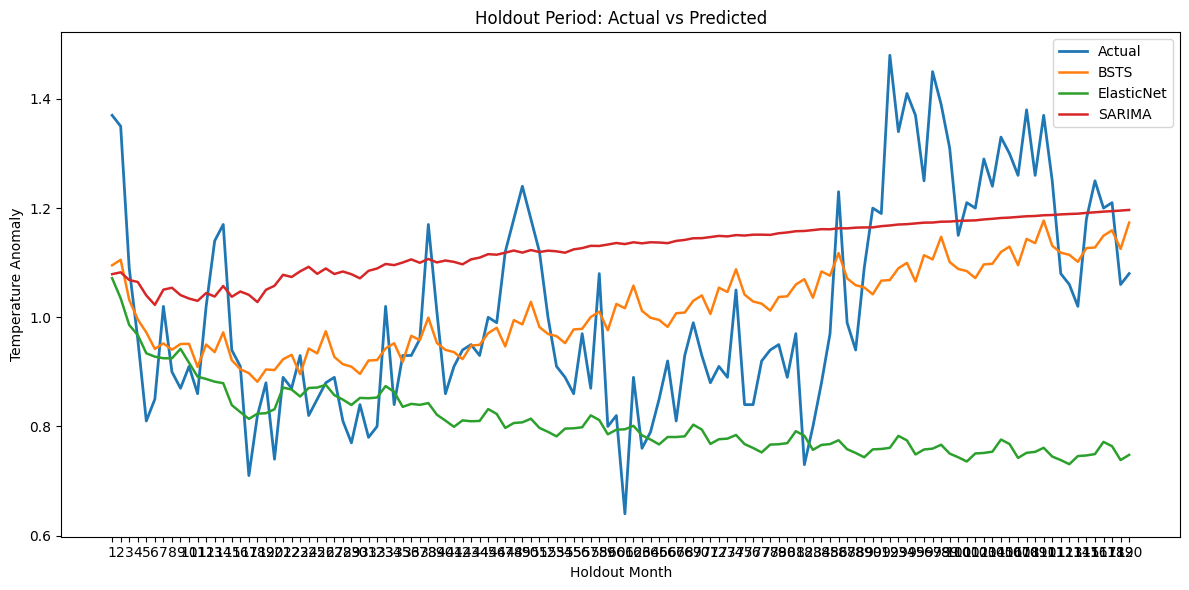

In [5]:
# 6. VISUAL 1: HOLDOUT FORECASTS

y_true = baseline_holdout_actual
n_test = len(y_true)
x = np.arange(1, n_test + 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y_true, linewidth=2, label="Actual")

for model_name, obj in results.items():
    plt.plot(x, obj["holdout_pred"], linewidth=1.8, label=model_name)

plt.title("Holdout Period: Actual vs Predicted")
plt.xlabel("Holdout Month")
plt.ylabel("Temperature Anomaly")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

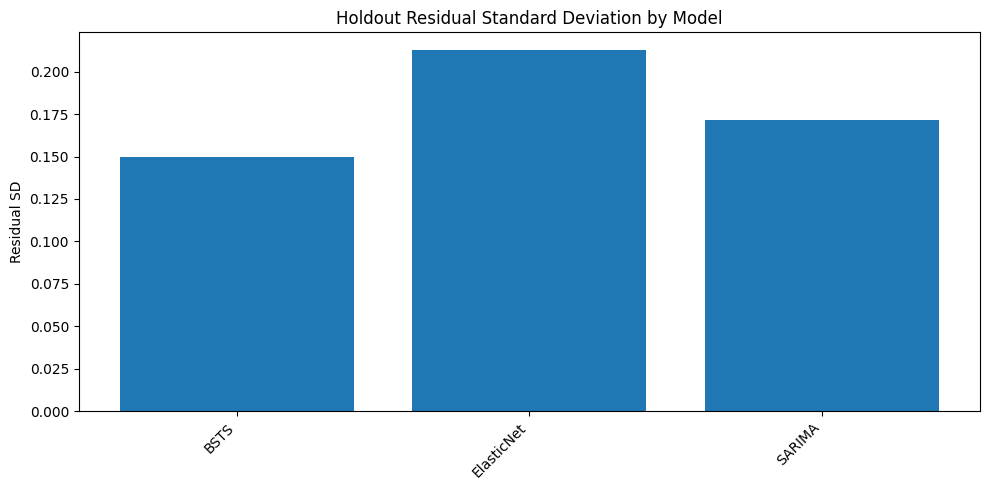

In [6]:
# HOLDOUT RESIDUALS BY MODEL

model_names = list(results.keys())
residual_stds = []
residual_means = []

for model_name in model_names:
    resid = results[model_name]["holdout_actual"] - results[model_name]["holdout_pred"]
    residual_means.append(np.mean(resid))
    residual_stds.append(np.std(resid, ddof=1))

xpos = np.arange(len(model_names))

plt.figure(figsize=(10, 5))
plt.bar(xpos, residual_stds)
plt.xticks(xpos, model_names, rotation=45, ha="right")
plt.title("Holdout Residual Standard Deviation by Model")
plt.ylabel("Residual SD")
plt.tight_layout()
plt.show()

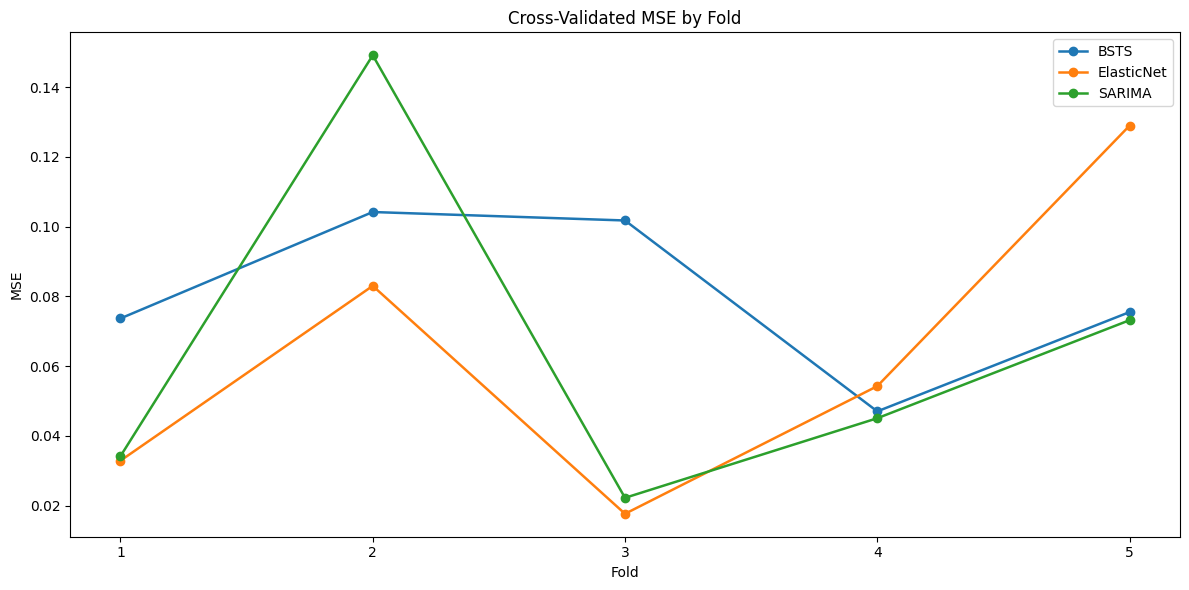

In [8]:
# 8. CV ERROR BY FOLD
baseline_cv_len = len(next(iter(results.values()))["cv_errors"])
fold_ids = np.arange(1, baseline_cv_len + 1)

plt.figure(figsize=(12, 6))
for model_name, obj in results.items():
    plt.plot(fold_ids, obj["cv_errors"], marker="o", linewidth=1.8, label=model_name)

plt.title(f"Cross-Validated {metric_name} by Fold")
plt.xlabel("Fold")
plt.ylabel(metric_name)
plt.xticks(fold_ids)
plt.legend()
plt.tight_layout()
plt.show()

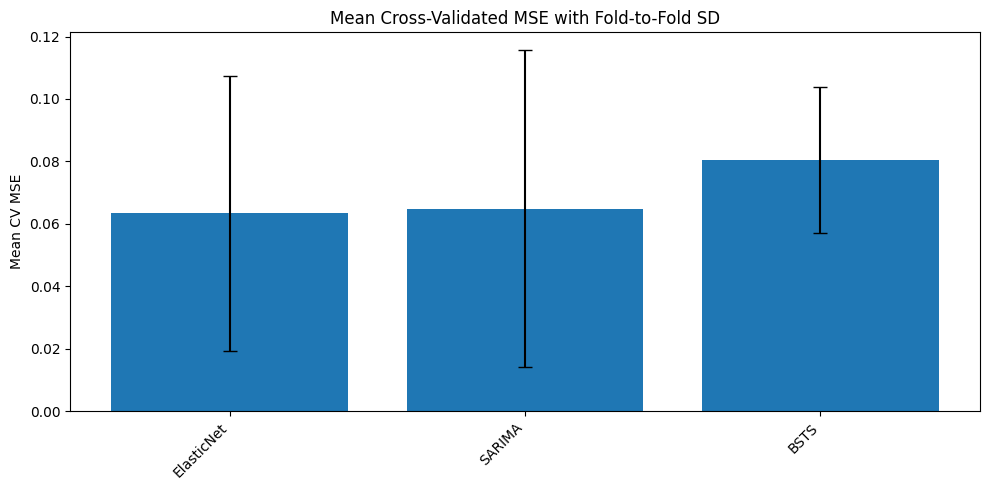

In [9]:
# MEAN CV ERROR WITH ERROR BAR

plot_df = summary_df.sort_values(by=f"Mean CV {metric_name}").copy()

means = plot_df[f"Mean CV {metric_name}"].values
sds = plot_df[f"SD CV {metric_name}"].values
labels = plot_df["Model"].values
xpos = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.bar(xpos, means, yerr=sds, capsize=5)
plt.xticks(xpos, labels, rotation=45, ha="right")
plt.ylabel(f"Mean CV {metric_name}")
plt.title(f"Mean Cross-Validated {metric_name} with Fold-to-Fold SD")
plt.tight_layout()
plt.show()

In [10]:
# BOOTSTRAP CI FOR DIFFERENCE VS SARIMA

comp_rows = []

for model_name, obj in results.items():
    if model_name == BASELINE_MODEL:
        continue
    
    diff = obj["cv_errors"] - baseline_cv
    mean_diff, ci_low, ci_high, _ = bootstrap_mean_ci(
        diff, B=BOOTSTRAP_B, seed=RANDOM_SEED
    )
    
    comp_rows.append({
        "Model": model_name,
        "MeanDiff": mean_diff,
        "CILow": ci_low,
        "CIHigh": ci_high
    })

comp_df = pd.DataFrame(comp_rows).sort_values(by="MeanDiff")
comp_df

,Model,MeanDiff,CILow,CIHigh
1,ElasticNet,-0.001749,-0.038095,0.032295
0,BSTS,0.015996,-0.018606,0.055509


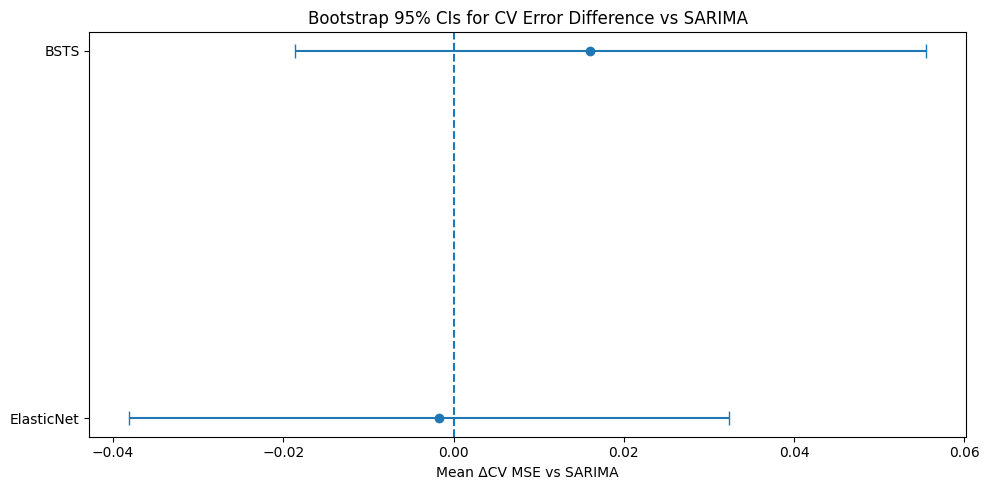

In [11]:
labels = comp_df["Model"].values
means = comp_df["MeanDiff"].values
lows = comp_df["CILow"].values
highs = comp_df["CIHigh"].values

xpos = np.arange(len(labels))
lower_err = means - lows
upper_err = highs - means

plt.figure(figsize=(10, 5))
plt.errorbar(
    means, xpos,
    xerr=[lower_err, upper_err],
    fmt="o",
    capsize=5
)
plt.axvline(0, linestyle="--")
plt.yticks(xpos, labels)
plt.xlabel(f"Mean ΔCV {metric_name} vs {BASELINE_MODEL}")
plt.title(f"Bootstrap 95% CIs for CV Error Difference vs {BASELINE_MODEL}")
plt.tight_layout()
plt.show()

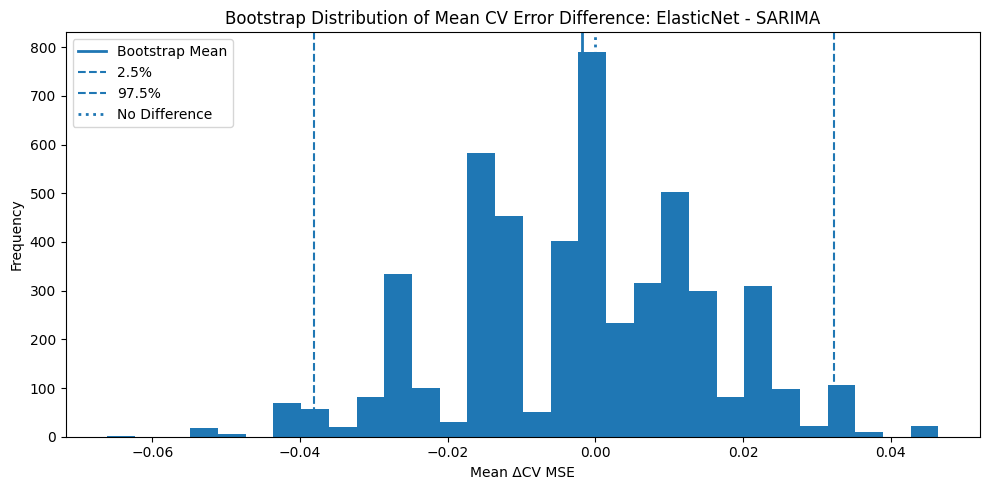

In [12]:
# BOOTSTRAP DISTRIBUTION FOR ONE MODEL

selected_model = comp_df.iloc[0]["Model"]  # best by mean difference

diff = results[selected_model]["cv_errors"] - baseline_cv
mean_diff, ci_low, ci_high, boot_dist = bootstrap_mean_ci(
    diff, B=BOOTSTRAP_B, seed=RANDOM_SEED
)

plt.figure(figsize=(10, 5))
plt.hist(boot_dist, bins=30)
plt.axvline(mean_diff, linestyle="-", linewidth=2, label="Bootstrap Mean")
plt.axvline(ci_low, linestyle="--", label="2.5%")
plt.axvline(ci_high, linestyle="--", label="97.5%")
plt.axvline(0, linestyle=":", linewidth=2, label="No Difference")
plt.title(f"Bootstrap Distribution of Mean CV Error Difference: {selected_model} - {BASELINE_MODEL}")
plt.xlabel(f"Mean ΔCV {metric_name}")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# INTERPRETATION FLAGS

def superiority_flag(ci_low, ci_high):
    if ci_high < 0:
        return "Better than baseline"
    elif ci_low > 0:
        return "Worse than baseline"
    else:
        return "Not clearly different"

comp_df["Interpretation"] = [
    superiority_flag(lo, hi) for lo, hi in zip(comp_df["CILow"], comp_df["CIHigh"])
]

comp_df_rounded = comp_df.copy()
for col in ["MeanDiff", "CILow", "CIHigh"]:
    comp_df_rounded[col] = comp_df_rounded[col].round(4)

comp_df_rounded

,Model,MeanDiff,CILow,CIHigh,Interpretation
1,ElasticNet,-0.0017,-0.0381,0.0323,Not clearly different
0,BSTS,0.0160,-0.0186,0.0555,Not clearly different


In [14]:
# SAVE TABLES

summary_df.to_csv("model_comparison_summary.csv", index=False)
comp_df.to_csv("model_vs_baseline_bootstrap_ci.csv", index=False)

print("Saved:")
print("- model_comparison_summary.csv")
print("- model_vs_baseline_bootstrap_ci.csv")

Saved:
- model_comparison_summary.csv
- model_vs_baseline_bootstrap_ci.csv
